In [1]:
from pathlib import Path
import os
import sys

import mne

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%matplotlib qt

Channels marked as bad:
none


In [2]:
from modules.decode_trigger import decode_8bit_trigger, convert_dict_trigger
from modules.events import get_events_tms_per_task

In [3]:
raw_data = mne.io.read_raw_bdf(r"data/raw/V1.bdf", preload=True)

Extracting BDF parameters from data/raw/V1.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 12594999  =      0.000 ...  2519.000 secs...


In [4]:
emg_ch_names = ["EMG L", "EMG R"]
eog_ch_names = ["EOG"]
raw_data.set_channel_types({ch: "emg" for ch in emg_ch_names})
raw_data.set_channel_types({'EOG':'eog'})

montage = mne.channels.make_standard_montage("standard_1020",head_size='auto')
raw_data.set_montage(montage)

<RawBDF | V1.bdf, 67 x 12595000 (2519.0 s), ~6.29 GiB, data loaded>

In [5]:
events, event_id = mne.events_from_annotations(raw_data)
event_id = raw_data.event_id = convert_dict_trigger(event_id, decode_8bit_trigger)

Used Annotations descriptions: [np.str_('8Bit 1'), np.str_('8Bit 10'), np.str_('8Bit 2'), np.str_('8Bit 3'), np.str_('8Bit 4'), np.str_('8Bit 5'), np.str_('Stimulus A')]


Using matplotlib as 2D backend.


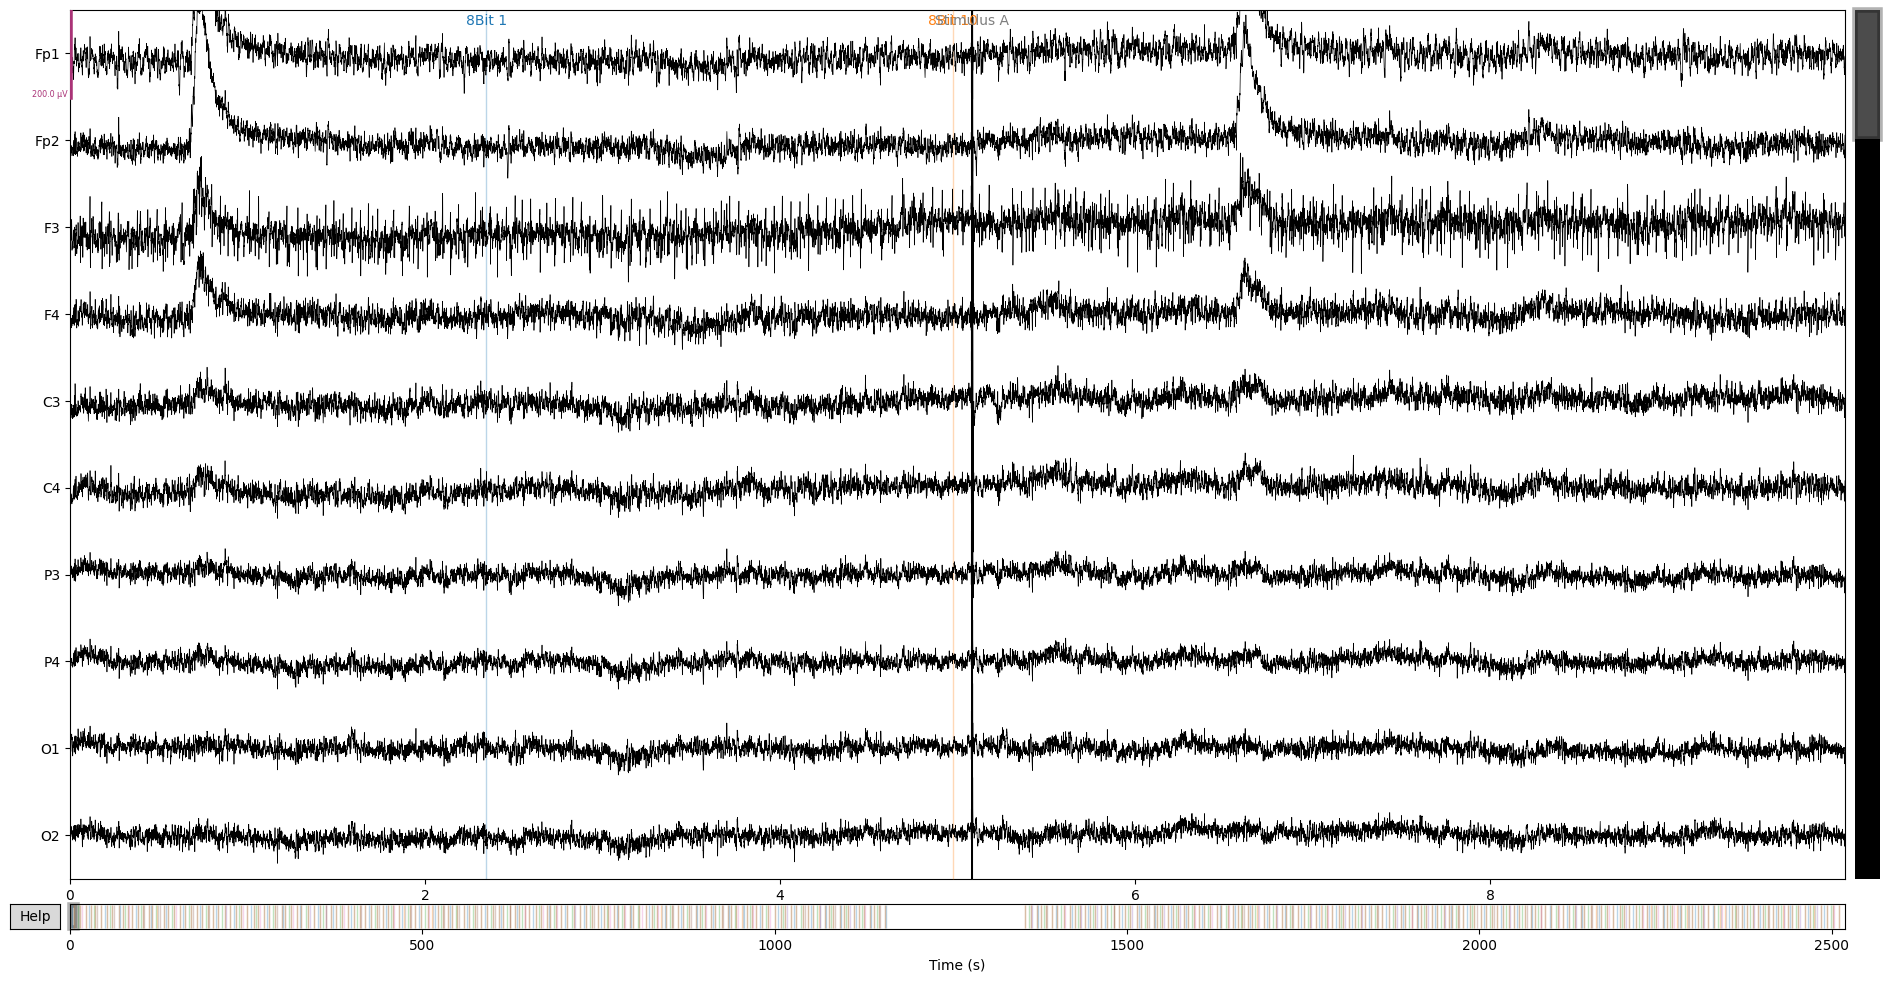

In [6]:
raw_data.plot(scalings={"eeg": 100e-6, "emg": 500e-6, "eog": 200e-6}, n_channels=10)

In [8]:
bad_ch =['F7', 'F5', 'P7', 'CPz', 'Oz', 'Iz', 'PO4', 'PO8', 'O2', "P6", "P8", "TP8", "C6", "TP10", "TP9", "F6", "FT8", "T8", "T7", "F3", "FC5", "FC3", "C3", "C1"]
raw_data.drop_channels(bad_ch)

<RawBDF | V1.bdf, 43 x 12595000 (2519.0 s), ~4.04 GiB, data loaded>

In [9]:
events_left, events_right, events_bilateral = get_events_tms_per_task(events, event_id)

In [10]:
epochs_left = mne.Epochs(
    raw_data,
    events_left,
    tmin=-0.8,
    tmax=0.8,
    baseline=(-0.25,-0.1),
    preload=True,
    detrend=1,
)

Not setting metadata
36 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 36 events and 8001 original time points ...
0 bad epochs dropped


In [11]:
raw_epochs = epochs_left.copy().crop(tmin=-0.015, tmax=0.035)
raw_epochs = mne.preprocessing.fix_stim_artifact(
    raw_epochs, 
    events=epochs_left.events,
    event_id=epochs_left.event_id,
    tmin=-0.004,  # -2 ms
    tmax=0.018, # 10 ms
    mode='linear'
)

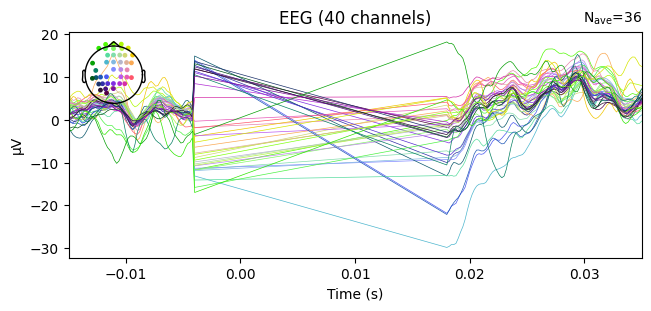

In [12]:
raw_epochs.average().plot()

In [13]:
epochs_clean_left = mne.preprocessing.fix_stim_artifact(
    epochs_left, 
    events=epochs_left.events,
    event_id=epochs_left.event_id,
    tmin=-0.005,  # -2 ms
    tmax=0.018,   # 10 ms
    mode='linear'
)

Need more than one channel to make topography for eeg. Disabling interactivity.


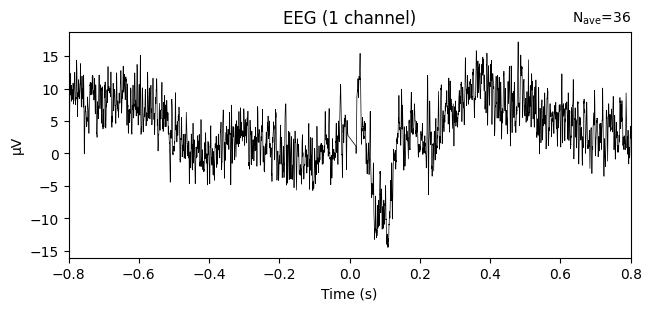

In [14]:
epochs_clean_left.average().plot(picks='C4')

In [16]:
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(epochs_clean_left)

Fitting ICA to data using 40 channels (please be patient, this may take a while)


C:\Users\marci\AppData\Local\Temp\ipykernel_12192\2516324062.py:2: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs_clean_left)
C:\Users\marci\AppData\Local\Temp\ipykernel_12192\2516324062.py:2: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs_clean_left)


Selecting by number: 20 components
Fitting ICA took 8.9s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=800
Fit,47 iterations on epochs (288036 samples)
ICA components,20
Available PCA components,40
Channel types,eeg
ICA components marked for exclusion,—


Not setting metadata
36 matching events found
No baseline correction applied
0 projection items activated


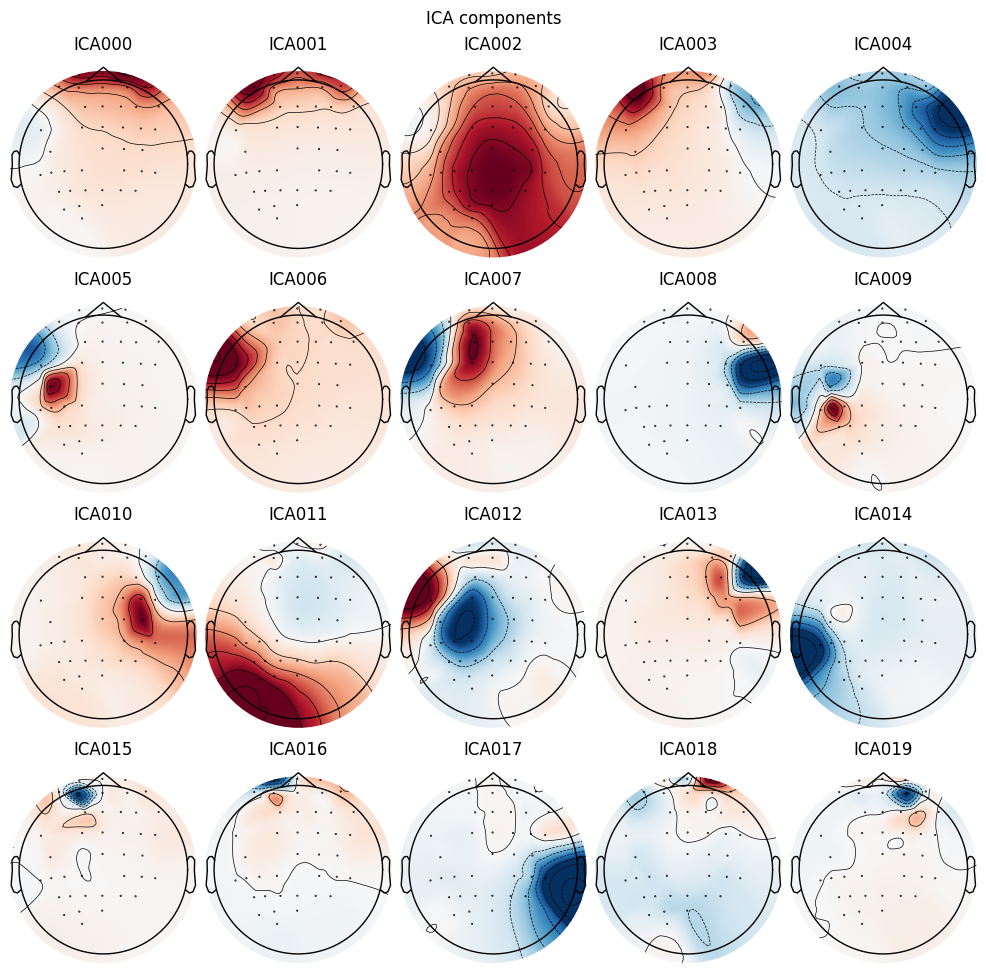

In [18]:
ica.plot_sources(epochs_clean_left, show_scrollbars=True)
ica.plot_components(inst=epochs_clean_left)

In [19]:
ica.exclude = [0,1]
epochs_clean_left = ica.apply(epochs_clean_left.copy())

Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 40 PCA components


C:\Users\marci\AppData\Local\Temp\ipykernel_12192\2884354493.py:2: RuntimeWarning: The data you passed to ICA.apply() was baseline-corrected. Please note that ICA can introduce DC shifts, therefore you may wish to consider baseline-correcting the cleaned data again.
  epochs_clean_left = ica.apply(epochs_clean_left.copy())


In [20]:
epochs_clean_left.apply_baseline(baseline=(-0.250, -0.1))

Applying baseline correction (mode: mean)


<Epochs | 36 events (all good), -0.8 – 0.8 s (baseline -0.25 – -0.1 s), ~94.6 MiB, data loaded,
 '1': 36>

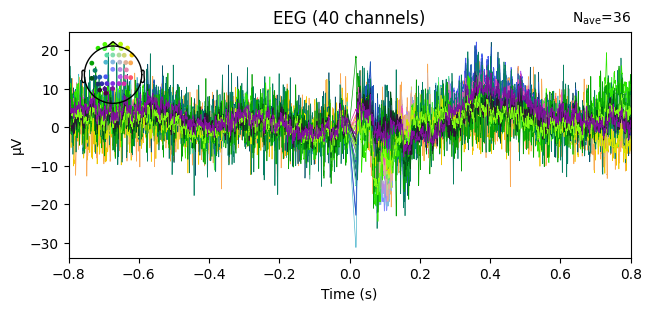

In [22]:
epochs_clean_left.average().plot()

In [23]:
epochs_clean_left.filter(l_freq=1,h_freq=75, fir_design='firwin')

Setting up band-pass filter from 1 - 75 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 75.00 Hz
- Upper transition bandwidth: 18.75 Hz (-6 dB cutoff frequency: 84.38 Hz)
- Filter length: 16501 samples (3.300 s)



C:\Users\marci\AppData\Local\Temp\ipykernel_12192\1202940500.py:1: RuntimeWarning: filter_length (16501) is longer than the signal (8001), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_clean_left.filter(l_freq=1,h_freq=75, fir_design='firwin')


<Epochs | 36 events (all good), -0.8 – 0.8 s (baseline -0.25 – -0.1 s), ~94.6 MiB, data loaded,
 '1': 36>

In [26]:
evoked = epochs_clean_left.average()  # média de todas as épocas

In [27]:
evoked.apply_baseline(baseline=(-0.250, -0.05))

Applying baseline correction (mode: mean)


<Evoked | '1' (average, N=36), -0.8 – 0.8 s, baseline -0.25 – -0.05 s, 40 ch, ~2.5 MiB>

Need more than one channel to make topography for eeg. Disabling interactivity.


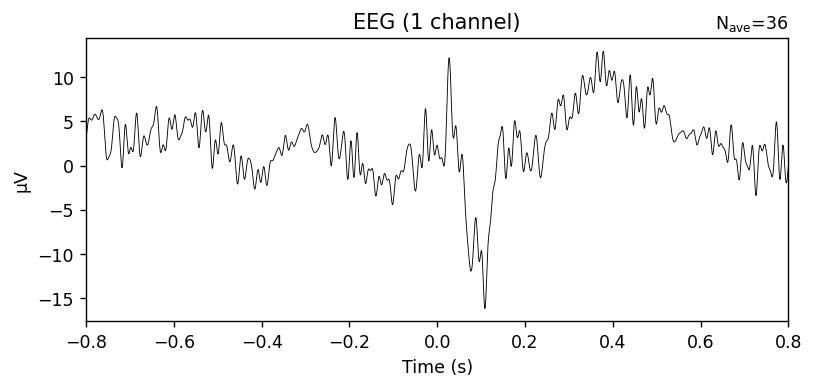

In [28]:
evoked.plot(picks='C4')